In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import datetime

# Point this to YOUR generated split folder
SPLIT = "train"
REPO_ROOT = Path.cwd().parent
BASE_DIR = REPO_ROOT / "data" / "generated" / "train"
MANIFEST = BASE_DIR / "manifests" / "train_manifest.jsonl"

print("Manifest exists:", MANIFEST.exists())
print("Modified:", datetime.datetime.fromtimestamp(MANIFEST.stat().st_mtime))
print("Size:", MANIFEST.stat().st_size)


Manifest exists: True
Modified: 2026-03-23 22:10:45.216048
Size: 4240608


In [2]:
def load_manifest_rows(manifest_path: Path, max_rows: int | None = None):
    rows = []
    with manifest_path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            rows.append(json.loads(line))
    return rows

rows = load_manifest_rows(MANIFEST, max_rows=500)  # load first 500 for quick browsing
print("Loaded rows:", len(rows))

# Pick one example
row = rows[250]
row["ex_id"], row["clean_audio_path"], row["labels_path"]

Loaded rows: 500


('train_0000250',
 'clean_audio/train_0000250.npy',
 'labels/train_0000250_y.npy')

In [3]:
sr = int(row["sr"])
x = np.load(BASE_DIR / row["clean_audio_path"])
y = np.load(BASE_DIR / row["labels_path"])

hop_s = float(row["frame_params"]["hop_ms"]) / 1000.0

print("ex_id:", row["ex_id"])
print("audio:", x.shape, x.dtype, "sec:", x.size / sr)
print("labels:", y.shape, y.dtype, "label duration sec:", y.size * hop_s)
print("speech frame %:", 100 * y.mean())

print("Speech frames:", np.sum(y))
print("Non-speech frames:", len(y) - np.sum(y))

ex_id: train_0000250
audio: (240379,) float32 sec: 15.0236875
labels: (1500,) uint8 label duration sec: 15.0
speech frame %: 69.93333333333334
Speech frames: 1049
Non-speech frames: 451.0


In [4]:
sr = int(row["sr"])

speech_sec = sum((s["end"] - s["start"]) for s in row["speech_intervals"]) / sr
sil_sec = sum((s["end"] - s["start"]) for s in row["silences"]) / sr
total = speech_sec + sil_sec

print("n_utts:", len(row["utterances"]))
print("speech_sec:", round(speech_sec, 2))
print("sil_sec:", round(sil_sec, 2))
print("speech_ratio_from_intervals:", round(speech_sec/total, 4))
print("utt_durations:", [round((u["end"]-u["start"])/sr,2) for u in row["utterances"]])
print("sil_durations:", [round((s["end"]-s["start"])/sr,2) for s in row["silences"]])

n_utts: 3
speech_sec: 10.5
sil_sec: 4.52
speech_ratio_from_intervals: 0.6989
utt_durations: [3.5, 3.5, 3.5]
sil_durations: [0.68, 1.58, 2.26]


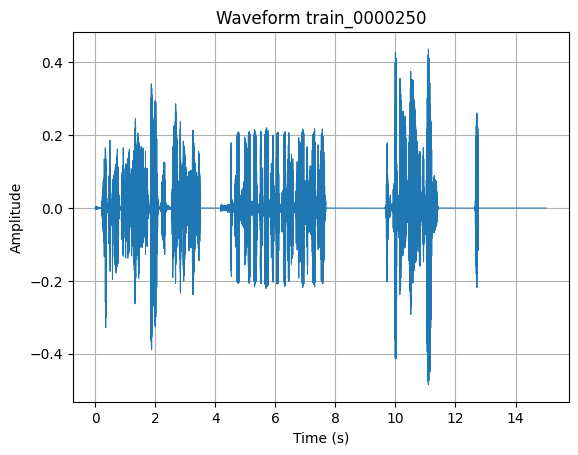

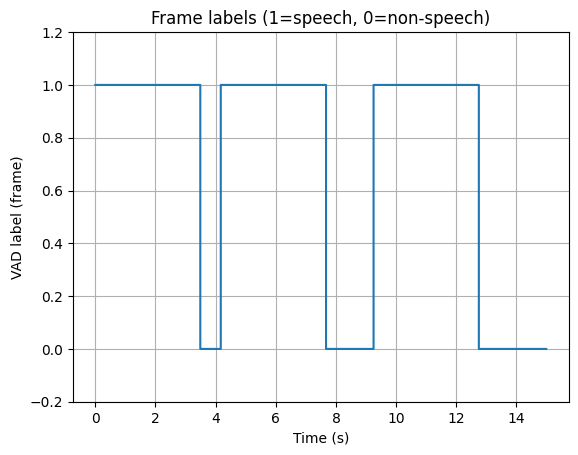

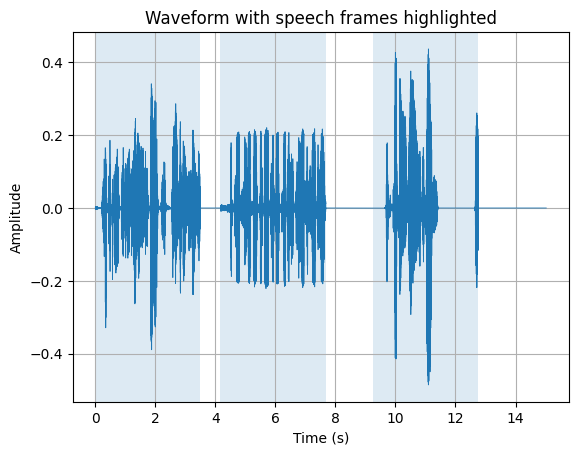

In [5]:
def plot_wave_and_labels(x, y, sr, hop_s, title="", max_sec=None):
    if max_sec is not None:
        x = x[: int(max_sec * sr)]
        y = y[: int(max_sec / hop_s)]

    t_audio = np.arange(x.size) / sr
    t_frames = np.arange(y.size) * hop_s

    # Waveform
    plt.figure()
    plt.plot(t_audio, x, linewidth=0.7)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Waveform {title}")
    plt.grid(True)
    plt.show()

    # Labels
    plt.figure()
    plt.step(t_frames, y, where="post")
    plt.ylim(-0.2, 1.2)
    plt.xlabel("Time (s)")
    plt.ylabel("VAD label (frame)")
    plt.title("Frame labels (1=speech, 0=non-speech)")
    plt.grid(True)
    plt.show()

    # Overlay highlight speech frames
    plt.figure()
    plt.plot(t_audio, x, linewidth=0.6)
    for k, lab in enumerate(y):
        if lab == 1:
            t0 = k * hop_s
            t1 = (k + 1) * hop_s
            plt.axvspan(t0, t1, alpha=0.15)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Waveform with speech frames highlighted")
    plt.grid(True)
    plt.show()

plot_wave_and_labels(x, y, sr, hop_s, title=row["ex_id"], max_sec=25)

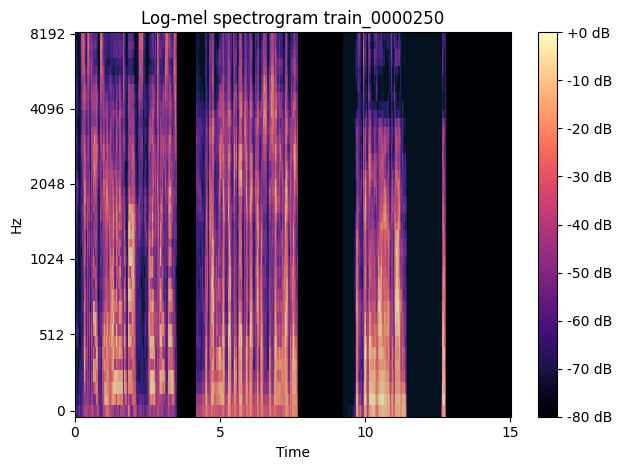

In [6]:
def plot_logmel_with_labels(x, y, sr, hop_s, title="", max_sec=25, n_mels=40):
    x = x[: int(max_sec * sr)]
    y = y[: int(max_sec / hop_s)]

    # Use your same framing defaults: 25ms win (400 samples), 10ms hop (160 samples)
    win_length = 400
    hop_length = 160

    S = librosa.feature.melspectrogram(
        y=x,
        sr=sr,
        n_fft=win_length,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure()
    librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Log-mel spectrogram {title}")

    # overlay labels
    for k, lab in enumerate(y):
        if lab == 1:
            t0 = k * hop_s
            t1 = (k + 1) * hop_s
            plt.axvspan(t0, t1, alpha=0.15)

    plt.tight_layout()
    plt.show()

plot_logmel_with_labels(x, y, sr, hop_s, title=row["ex_id"], max_sec=25)

In [7]:
def load_jsonl(path: Path, max_rows=None):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            rows.append(json.loads(line))
    return rows

rows = load_jsonl(MANIFEST, max_rows=None)  # set e.g. 500 if you want faster
print("Loaded:", len(rows))
print("Example keys:", list(rows[0].keys()))

Loaded: 3000
Example keys: ['ex_id', 'split', 'sr', 'clean_audio_path', 'num_samples', 'utterances', 'speech_intervals', 'silences', 'labels_path', 'frame_params', 'standardize', 'source', 'seed', 'ex_seed']


In [8]:
def safe_get_num_utts(row):
    # depending on how you saved it
    if "utterances" in row:
        return len(row["utterances"])
    if "utter_meta" in row:
        return len(row["utter_meta"])
    if "utters" in row:
        return len(row["utters"])
    if "utt_ids" in row:
        return len(row["utt_ids"])
    return None

speech_ratios = []
durations = []
num_utts_list = []
silence_lengths = []

missing_silences = 0
missing_num_utts = 0

for r in rows:
    sr = int(r["sr"])

    # duration from waveform length (most reliable)
    x = np.load(BASE_DIR / r["clean_audio_path"])
    dur_s = x.size / sr
    durations.append(dur_s)

    # number of utterances
    n_utts = safe_get_num_utts(r)
    if n_utts is None:
        missing_num_utts += 1
    else:
        num_utts_list.append(n_utts)

    # silence lengths (needs "silences" saved in manifest)
    sil = r.get("silences", None)
    if sil is None:
        missing_silences += 1
        sil_total = None
    else:
        sil_lens = [(s["end"] - s["start"]) / sr for s in sil]
        silence_lengths.extend(sil_lens)
        sil_total = sum(sil_lens)

    # speech ratio:
    # Option A: from labels (if you have them)
    if "labels_path" in r:
        y = np.load(BASE_DIR / r["labels_path"])
        speech_ratios.append(float(np.mean(y)))
    else:
        # Option B: from silences (speech approx = 1 - silence fraction)
        if sil_total is not None and dur_s > 0:
            speech_ratios.append(float(1.0 - sil_total / dur_s))

print("Examples:", len(rows))
print("Missing silences meta rows:", missing_silences)
print("Missing num_utts rows:", missing_num_utts)
print("Collected num_utts entries:", len(num_utts_list))
print("Collected silence segments:", len(silence_lengths))

Examples: 3000
Missing silences meta rows: 0
Missing num_utts rows: 0
Collected num_utts entries: 3000
Collected silence segments: 15411


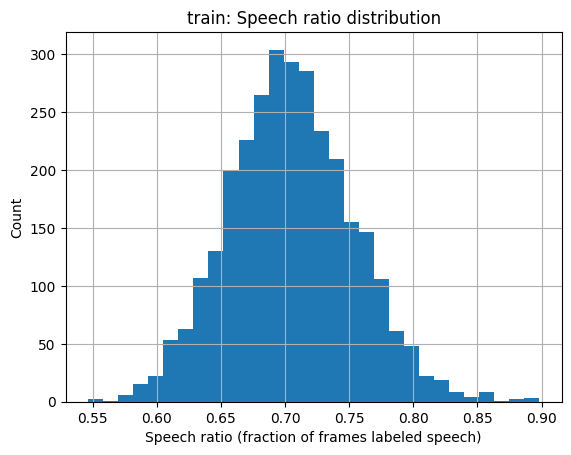

Speech ratio mean: 0.7046646444101277
Speech ratio median: 0.7033003945779825


In [9]:
plt.figure()
plt.hist(speech_ratios, bins=30)
plt.xlabel("Speech ratio (fraction of frames labeled speech)")
plt.ylabel("Count")
plt.title(f"{SPLIT}: Speech ratio distribution")
plt.grid(True)
plt.show()

print("Speech ratio mean:", np.mean(speech_ratios))
print("Speech ratio median:", np.median(speech_ratios))

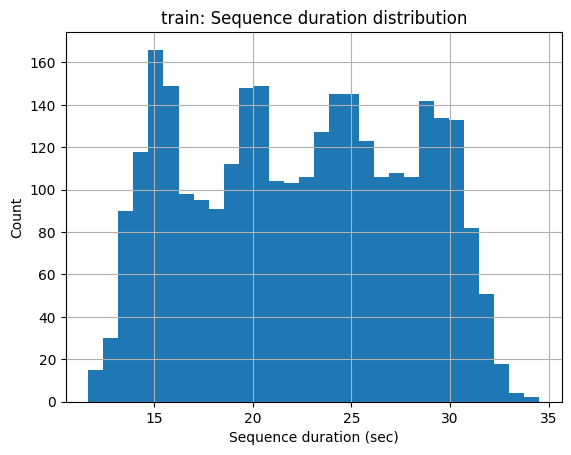

Duration mean (sec): 22.440377270833338
Duration median (sec): 22.575


In [10]:
plt.figure()
plt.hist(durations, bins=30)
plt.xlabel("Sequence duration (sec)")
plt.ylabel("Count")
plt.title(f"{SPLIT}: Sequence duration distribution")
plt.grid(True)
plt.show()

print("Duration mean (sec):", np.mean(durations))
print("Duration median (sec):", np.median(durations))

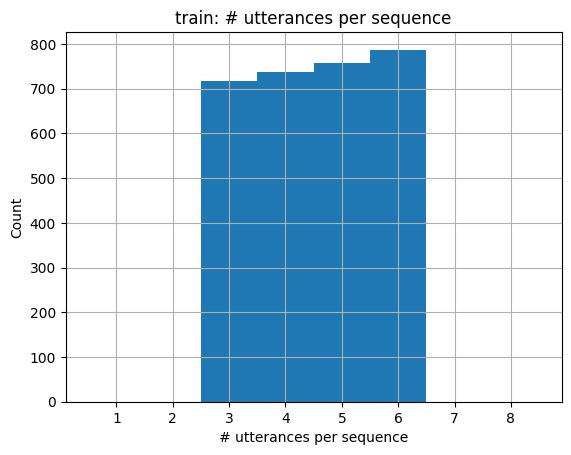

Num utts mean: 4.538


In [11]:
if len(num_utts_list) > 0:
    plt.figure()
    plt.hist(num_utts_list, bins=np.arange(1, 10) - 0.5)  # nice integer bins
    plt.xlabel("# utterances per sequence")
    plt.ylabel("Count")
    plt.title(f"{SPLIT}: # utterances per sequence")
    plt.grid(True)
    plt.show()

    print("Num utts mean:", np.mean(num_utts_list))
else:
    print("No utterance-count field found in manifest (utter_meta/utt_ids missing).")

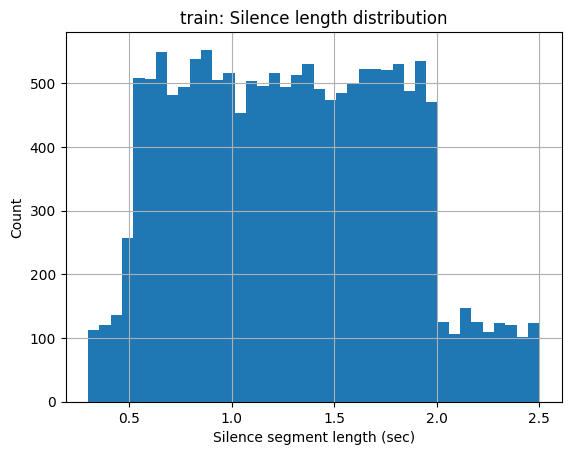

Silence mean (sec): 1.296306319349815
Silence median (sec): 1.2858125


In [12]:
if len(silence_lengths) > 0:
    plt.figure()
    plt.hist(silence_lengths, bins=40)
    plt.xlabel("Silence segment length (sec)")
    plt.ylabel("Count")
    plt.title(f"{SPLIT}: Silence length distribution")
    plt.grid(True)
    plt.show()

    print("Silence mean (sec):", np.mean(silence_lengths))
    print("Silence median (sec):", np.median(silence_lengths))
else:
    print("No 'silences' field found in manifest. Add it to manifest for this plot.")